In [1]:
import json
import os
import pprint
import numpy as np
import matplotlib.pyplot as plt
import scienceplots
from pprint import pprint
# import display to show images in the notebook
from IPython.display import display, Image
plt.style.use(['science', 'no-latex'])

with open("/research/hal-afsharim/learn-to-steer/Hallucination/POPE/hallucination/hallucination_metrics_llava_pope_test_steer_14_yes_no_popular_1_llava_14_average_all_pope_train_-1_model_prediction.json", "r") as f:
    data = json.load(f)
    
for key, value in data.items():
    print(f"{key}: {value}")

predictions: [['The image shows several people attentively looking at their laptop computers while sitting in a conference room. There are at least twelve people present in the room, with multiple people positioned close to each other.\n\nIn the scene, numerous chairs are arranged around the room with some chairs facing towards laptops. At least two laptops are open on a desk, with one of them displaying a blue background and the other showing white on its computer screen. The attendees can be seen sitting on their chairs, focused on the screens, and possibly learning or collaborating in the meeting.'], ['The image features a seminar session in which a group of people is seated in the audience, each focused on their computers. There is a noticeable concentration of individuals working behind their laptop screens.\n\nIn addition to the laptop screens, there is an array of cell phones and a second laptop being used by attendees in the room. A number of chairs are visible, many of which a

In [2]:
# with open("/research/hal-afsharim/learn-to-steer/data/coco/annotations_trainval2014/instances_val2014.json", "r") as f:
#     coco = json.load(f)
# coco.keys()

dict_keys(['info', 'images', 'licenses', 'annotations', 'categories'])

In [3]:
from pycocotools.coco import COCO

coco = COCO("/research/hal-afsharim/learn-to-steer/data/coco/annotations_trainval2014/instances_val2014.json")

# category id → name
cats = coco.loadCats(coco.getCatIds())
id_to_name = {c['id']: c['name'] for c in cats}


# image_id → set of object names
gt_objects = {}

for img_id in coco.getImgIds():
    ann_ids = coco.getAnnIds(imgIds=img_id)
    anns = coco.loadAnns(ann_ids)

    objs = set()
    for ann in anns:
        objs.add(id_to_name[ann['category_id']])

    gt_objects[img_id] = objs
    



loading annotations into memory...
Done (t=7.32s)
creating index...
index created!


In [5]:
gt_objects

{391895: {'bicycle', 'motorcycle', 'person'},
 522418: {'cake', 'knife', 'person', 'sink'},
 184613: {'cow', 'person', 'umbrella'},
 318219: {'keyboard', 'mouse', 'person', 'tv'},
 554625: {'keyboard', 'mouse', 'person', 'tv'},
 397133: {'bottle',
  'bowl',
  'broccoli',
  'carrot',
  'cup',
  'dining table',
  'knife',
  'oven',
  'person',
  'sink',
  'spoon'},
 574769: {'bottle',
  'bowl',
  'cat',
  'clock',
  'handbag',
  'orange',
  'oven',
  'person',
  'potted plant',
  'refrigerator',
  'sink',
  'spoon'},
 60623: {'bowl', 'dining table', 'person', 'spoon', 'wine glass'},
 309022: {'bottle', 'bowl', 'oven', 'sink'},
 5802: {'backpack', 'bottle', 'bowl', 'cup', 'knife', 'person'},
 222564: {'bottle', 'dining table', 'microwave', 'oven', 'person'},
 118113: {'book', 'bottle', 'dining table', 'oven'},
 193271: {'bottle',
  'bowl',
  'cup',
  'fork',
  'microwave',
  'oven',
  'sink',
  'spoon',
  'toaster',
  'wine glass'},
 224736: {'sink', 'toilet'},
 483108: {'bicycle', 'perso

In [6]:
# find the basename of the image path
os.path.basename(data["images"][0][0])
# find the image id from the basename
image_id = int(os.path.basename(data["images"][0][0]).split(".")[0].split("_")[-1])
image_id

429033

In [7]:
gt_objects[image_id]

{'chair', 'laptop', 'person'}

('The image shows several people attentively looking at their laptop computers '
 'while sitting in a conference room. There are at least twelve people present '
 'in the room, with multiple people positioned close to each other.\n'
 '\n'
 'In the scene, numerous chairs are arranged around the room with some chairs '
 'facing towards laptops. At least two laptops are open on a desk, with one of '
 'them displaying a blue background and the other showing white on its '
 'computer screen. The attendees can be seen sitting on their chairs, focused '
 'on the screens, and possibly learning or collaborating in the meeting.')


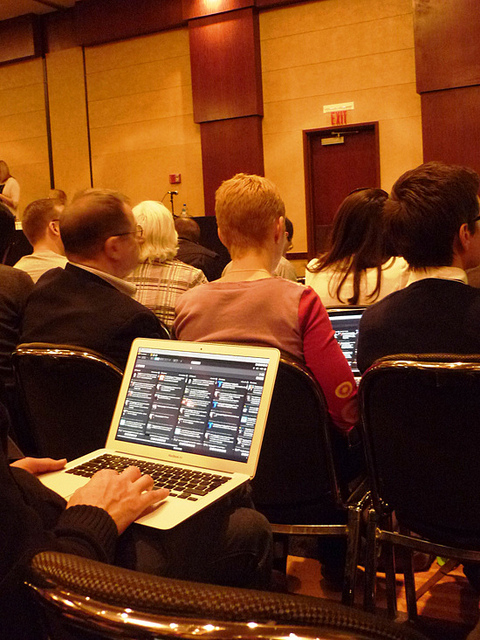

In [8]:
i = 0
pprint(data["predictions"][i][0])
# display the image
display(Image(data["images"][i][0]))

In [9]:
COCO_OBJECTS = set(id_to_name.values())
COCO_OBJECTS

{'airplane',
 'apple',
 'backpack',
 'banana',
 'baseball bat',
 'baseball glove',
 'bear',
 'bed',
 'bench',
 'bicycle',
 'bird',
 'boat',
 'book',
 'bottle',
 'bowl',
 'broccoli',
 'bus',
 'cake',
 'car',
 'carrot',
 'cat',
 'cell phone',
 'chair',
 'clock',
 'couch',
 'cow',
 'cup',
 'dining table',
 'dog',
 'donut',
 'elephant',
 'fire hydrant',
 'fork',
 'frisbee',
 'giraffe',
 'hair drier',
 'handbag',
 'horse',
 'hot dog',
 'keyboard',
 'kite',
 'knife',
 'laptop',
 'microwave',
 'motorcycle',
 'mouse',
 'orange',
 'oven',
 'parking meter',
 'person',
 'pizza',
 'potted plant',
 'refrigerator',
 'remote',
 'sandwich',
 'scissors',
 'sheep',
 'sink',
 'skateboard',
 'skis',
 'snowboard',
 'spoon',
 'sports ball',
 'stop sign',
 'suitcase',
 'surfboard',
 'teddy bear',
 'tennis racket',
 'tie',
 'toaster',
 'toilet',
 'toothbrush',
 'traffic light',
 'train',
 'truck',
 'tv',
 'umbrella',
 'vase',
 'wine glass',
 'zebra'}

In [11]:
import spacy

nlp = spacy.load("en_core_web_sm")

def extract_objects(caption):
    doc = nlp(caption.lower())

    objects = set()

    for token in doc:
        # only nouns
        if token.pos_ in ["NOUN", "PROPN"]:
            lemma = token.lemma_

            if lemma in COCO_OBJECTS:
                objects.add(lemma)

    return objects

In [14]:
import spacy
nlp = spacy.load("en_core_web_sm")

SYNONYMS = {
    "television": "tv",
    "sofa": "couch",
    "bike": "bicycle",
    "motorbike": "motorcycle",
    "plane": "airplane"
}

def normalize(word):
    return SYNONYMS.get(word, word)

def extract_objects(caption, coco_objects):
    doc = nlp(caption.lower())
    objects = set()

    for token in doc:   # <-- token is defined here
        if token.pos_ in ["NOUN", "PROPN"]:
            lemma = normalize(token.lemma_)  # <-- valid usage
            if lemma in coco_objects:
                objects.add(lemma)

    return objects

In [16]:
def compute_chair(pred_objects, gt_objects):
    hallucinated = pred_objects - gt_objects

    if len(pred_objects) == 0:
        chair_i = 0.0
    else:
        chair_i = len(hallucinated) / len(pred_objects)

    chair_s = 1 if len(hallucinated) > 0 else 0

    return chair_i, chair_s

In [ ]:
# save data["predictions"][i][0] and # find the basename of the image path
os.path.basename(data["images"][0][0])
# find the image id from the basename
image_id = int(os.path.basename(data["images"][0][0]).split(".")[0].split("_")[-1])
# image_id so that I can load them by predictions.items()
for i in range(len(data["predictions"])):
    
data["predictions"][i][0]

'The image shows several people attentively looking at their laptop computers while sitting in a conference room. There are at least twelve people present in the room, with multiple people positioned close to each other.\n\nIn the scene, numerous chairs are arranged around the room with some chairs facing towards laptops. At least two laptops are open on a desk, with one of them displaying a blue background and the other showing white on its computer screen. The attendees can be seen sitting on their chairs, focused on the screens, and possibly learning or collaborating in the meeting.'

In [22]:
total_hallucinated = 0
total_predicted = 0
total_sentences = 0
sent_with_hallucination = 0

for i in range(len(data["predictions"])):
    caption = data["predictions"][i][0]
    img_id = int(os.path.basename(data["images"][i][0]).split(".")[0].split("_")[-1])

    pred_objs = extract_objects(caption, COCO_OBJECTS)
    gt_objs = gt_objects[img_id]

    hallucinated = pred_objs - gt_objs

    total_hallucinated += len(hallucinated)
    total_predicted += len(pred_objs)

    if len(hallucinated) > 0:
        sent_with_hallucination += 1

    total_sentences += 1

CHAIR_i = total_hallucinated / total_predicted
CHAIR_s = sent_with_hallucination / total_sentences
print(f"CHAIR_i: {CHAIR_i:.4f}")
print(f"CHAIR_s: {CHAIR_s:.4f}")

CHAIR_i: 0.3662
CHAIR_s: 0.5540


In [26]:
hallucinated

{'car', 'truck'}

('In the image, two young girls are playing outside on a sidewalk, enjoying '
 'their time together. One of the young girls is running while the other '
 'stands on a tennis court. The girls are wearing tennis attire and appear to '
 'be having fun during their game of tag.\n'
 '\n'
 'The scene also includes a couple of cars and a truck located nearby, '
 "suggesting that the girls' playground is situated in a residential or urban "
 'area. Overall, it is a lively outdoor scene featuring two children engaging '
 'in friendly, playful competition.')


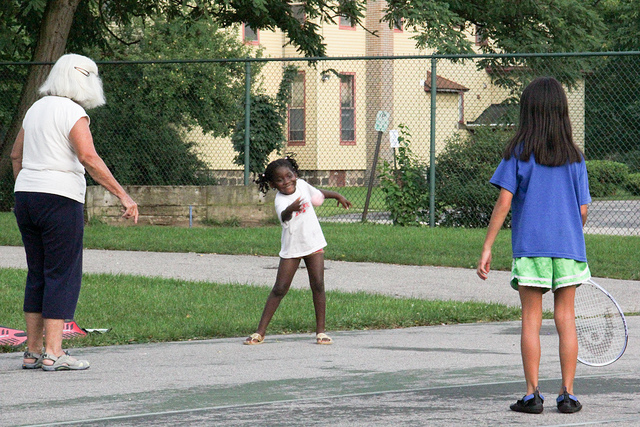

In [28]:
pprint(caption)
display(Image(data["images"][i][0]))